In [108]:
# meeting 2 tasks:
# practice by parsing elexon data from last 24h and combine relevant columns to form the 'matrix'


import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# assign variable to store file path
# we have past week + past 10 year files. check filename to distinguish. no issues with loading the data
file_path = 'GenerationByFuelType-2016-01-01T00_00_00.000Z-2026-06-15T14_30_00.000Z.csv'

# reads a csv file into a DataFrame
# a DataFrame is a 2D array and used for larger data sets 
df = pd.read_csv(file_path)



In [95]:
# DataFrame functions:
# prints first 5 rows by default (data appears formatted compared to printing it)
print('First 5 Rows: \n')
print(df.head(100))
print('\n')


print('All Info about DataFrame: \n')
df.info()


First 5 Rows: 

   Dataset           PublishTime             StartTime SettlementDate  \
0   FUELHH  2016-01-07T23:30:00Z  2016-01-07T23:00:00Z     2016-01-07   
1   FUELHH  2016-01-07T23:30:00Z  2016-01-07T23:00:00Z     2016-01-07   
2   FUELHH  2016-01-07T23:30:00Z  2016-01-07T23:00:00Z     2016-01-07   
3   FUELHH  2016-01-07T23:30:00Z  2016-01-07T23:00:00Z     2016-01-07   
4   FUELHH  2016-01-07T23:30:00Z  2016-01-07T23:00:00Z     2016-01-07   
..     ...                   ...                   ...            ...   
95  FUELHH  2016-01-07T20:00:00Z  2016-01-07T19:30:00Z     2016-01-07   
96  FUELHH  2016-01-07T20:00:00Z  2016-01-07T19:30:00Z     2016-01-07   
97  FUELHH  2016-01-07T20:00:00Z  2016-01-07T19:30:00Z     2016-01-07   
98  FUELHH  2016-01-07T20:00:00Z  2016-01-07T19:30:00Z     2016-01-07   
99  FUELHH  2016-01-07T20:00:00Z  2016-01-07T19:30:00Z     2016-01-07   

    SettlementPeriod FuelType  Generation  
0                 47     CCGT        8648  
1                 4

In [96]:
# pivot the data (long to wide format) i.e choose index labels (listed along side), column labels (listed across top) and values to fill the table 

# clean column names of empty spaces
df.columns = df.columns.str.strip()

# apply pivot function
df_pivot = df.pivot_table(
    index = ['SettlementDate', 'SettlementPeriod'],
    columns = 'FuelType',
    values = 'Generation',
    aggfunc = sum
)

# turn row labels back into columns
df_pivot = df_pivot.reset_index()



In [97]:
# check the pivoted data

print('First 5 rows: \n')
print(df_pivot.head())
print('\n')

df_pivot.info()

First 5 rows: 

FuelType SettlementDate  SettlementPeriod  BIOMASS    CCGT    COAL  INTELE  \
0            2016-01-01                 1      NaN  5716.0  3434.0     NaN   
1            2016-01-01                 2      NaN  6670.0  3583.0     NaN   
2            2016-01-01                 3      NaN  6985.0  3865.0     NaN   
3            2016-01-01                 4      NaN  6839.0  3772.0     NaN   
4            2016-01-01                 5      NaN  6775.0  3555.0     NaN   

FuelType  INTELEC  INTEW   INTFR  INTGRNL  ...  INTNEM  INTNSL  INTVKL  \
0             NaN  104.0  1756.0      NaN  ...     NaN     NaN     NaN   
1             NaN   26.0  1756.0      NaN  ...     NaN     NaN     NaN   
2             NaN   36.0  1756.0      NaN  ...     NaN     NaN     NaN   
3             NaN   64.0  1756.0      NaN  ...     NaN     NaN     NaN   
4             NaN   20.0  1756.0      NaN  ...     NaN     NaN     NaN   

FuelType  NPSHYD  NUCLEAR  OCGT  OIL   OTHER     PS    WIND  
0       

In [98]:
# combine relevant columns

# gas column
df_pivot ['Gas'] = df_pivot ['OCGT'] + df_pivot ['CCGT']


# interconnector column
int_columns = df_pivot.filter(like = 'INT') 
#print(int_columns)
df_pivot ['Int'] =  int_columns.sum(axis = 1) #axis=1 means add horizontally (for each row)


# hydroelectric column
df_pivot ['Hydro'] = df_pivot ['NPSHYD'] 

In [99]:
# create the final matrix

# copy columns to the final dataframe
final_matrix_df = df_pivot[
    ['SettlementDate', 
    'SettlementPeriod', 
    'Gas', 
    'NUCLEAR', 
    'Int', 
    'BIOMASS', 
    'Hydro',
     'COAL',
     'OIL',
     'PS',
     'WIND',
    'OTHER']
].copy()

# rename columns
final_matrix_df = final_matrix_df.rename(columns={
    'SettlementDate': 'Date',
    'SettlementPeriod': 'Period',
    'NUCLEAR': 'Nuclear',
    'BIOMASS': 'Biomass',
    'OIL':'Oil',
    'COAL':'Coal',
    'PS':'Pump Storage',
    'WIND':'Wind',
    'OTHER': 'Other'
})


final_matrix_df = final_matrix_df.sort_values(by=['Date', 'Period']) #sort by date first and then period
print(final_matrix_df.head(175200))



FuelType        Date  Period      Gas  Nuclear     Int  Biomass  Hydro  \
0         2016-01-01       1   5716.0   8289.0  2756.0      NaN  710.0   
1         2016-01-01       2   6670.0   8292.0  2688.0      NaN  659.0   
2         2016-01-01       3   6985.0   8297.0  2742.0      NaN  643.0   
3         2016-01-01       4   6839.0   8285.0  2694.0      NaN  642.0   
4         2016-01-01       5   6775.0   8279.0  2554.0      NaN  642.0   
...              ...     ...      ...      ...     ...      ...    ...   
175195    2025-12-31      32  10124.0   4079.0  2544.0   3066.0  502.0   
175196    2025-12-31      33  11852.0   4082.0  1488.0   3066.0  538.0   
175197    2025-12-31      34  13253.0   4084.0  1454.0   3065.0  559.0   
175198    2025-12-31      35  13491.0   4080.0  1856.0   3078.0  584.0   
175199    2025-12-31      36  13359.0   4083.0  1832.0   3083.0  593.0   

FuelType    Coal  Oil  Pump Storage     Wind   Other  
0         3434.0  0.0        -108.0   4675.0  2040.0  
1

Summer Day vs Winter Day
--------------
0    False
1    False
2    False
3    False
4    False
Name: Date, dtype: bool
FuelType       Date  Period     Gas  Nuclear     Int  Biomass  Hydro  Coal  \
182890   2026-06-10       1  5111.0   2971.0  4136.0   2393.0  380.0   0.0   
182891   2026-06-10       2  5018.0   2971.0  4130.0   2390.0  351.0   0.0   
182892   2026-06-10       3  5132.0   2969.0  3848.0   2385.0  276.0   0.0   
182893   2026-06-10       4  5101.0   2971.0  3940.0   2389.0  274.0   0.0   
182894   2026-06-10       5  4980.0   2973.0  3872.0   2390.0  252.0   0.0   

FuelType  Oil  Pump Storage    Wind  Other  Year  Month  Season  
182890    0.0         -12.0  7697.0  161.0  2026      6  Summer  
182891    0.0         -12.0  8024.0  137.0  2026      6  Summer  
182892    0.0         -10.0  7899.0  156.0  2026      6  Summer  
182893    0.0         -10.0  7725.0  160.0  2026      6  Summer  
182894    0.0         -10.0  7904.0  140.0  2026      6  Summer  
--------------
W

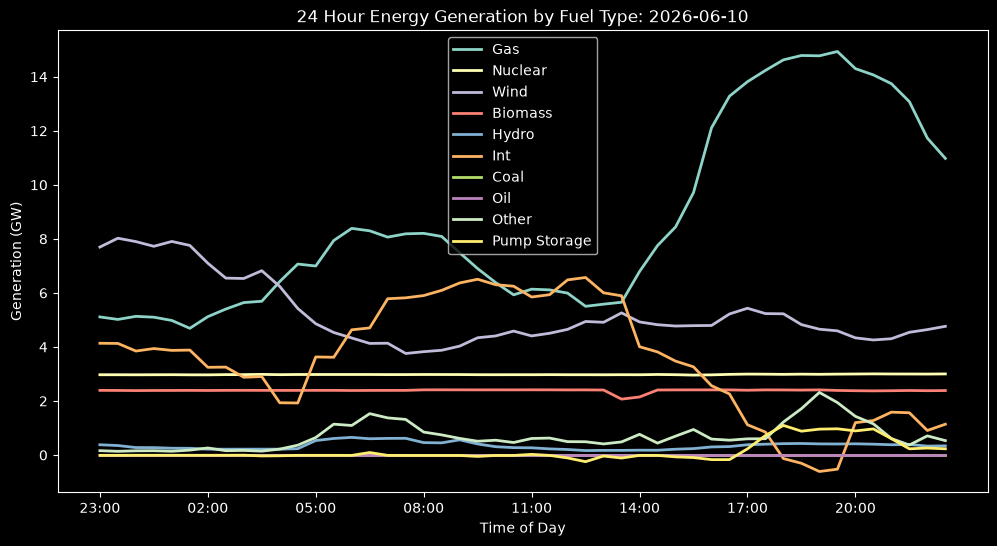

--------------
0    False
1    False
2    False
3    False
4    False
Name: Date, dtype: bool
FuelType       Date  Period     Gas  Nuclear     Int  Biomass  Hydro  Coal  \
175644   2026-01-10       1  6783.0   3808.0  6920.0   1409.0  254.0   0.0   
175645   2026-01-10       2  6874.0   3809.0  7048.0   1409.0  249.0   0.0   
175646   2026-01-10       3  6663.0   3808.0  7142.0   1408.0  245.0   0.0   
175647   2026-01-10       4  6517.0   3811.0  7066.0   1406.0  244.0   0.0   
175648   2026-01-10       5  6454.0   3810.0  7070.0   1409.0  242.0   0.0   

FuelType  Oil  Pump Storage     Wind  Other  Year  Month  Season  
175644    0.0          46.0  11309.0  261.0  2026      1  Winter  
175645    0.0        -124.0  11280.0  366.0  2026      1  Winter  
175646    0.0        -124.0  10990.0  348.0  2026      1  Winter  
175647    0.0        -122.0  10821.0  385.0  2026      1  Winter  
175648    0.0        -366.0  10486.0  458.0  2026      1  Winter  
--------------
With time column: 



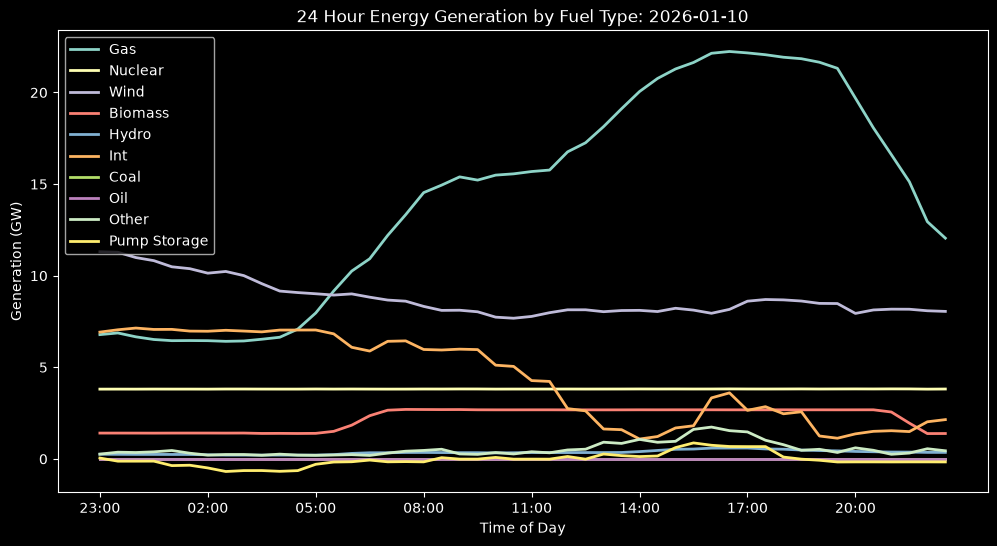

recent day vs old day
--------------
0    False
1    False
2    False
3    False
4    False
Name: Date, dtype: bool
FuelType       Date  Period     Gas  Nuclear     Int  Biomass  Hydro  Coal  \
182890   2026-06-10       1  5111.0   2971.0  4136.0   2393.0  380.0   0.0   
182891   2026-06-10       2  5018.0   2971.0  4130.0   2390.0  351.0   0.0   
182892   2026-06-10       3  5132.0   2969.0  3848.0   2385.0  276.0   0.0   
182893   2026-06-10       4  5101.0   2971.0  3940.0   2389.0  274.0   0.0   
182894   2026-06-10       5  4980.0   2973.0  3872.0   2390.0  252.0   0.0   

FuelType  Oil  Pump Storage    Wind  Other  Year  Month  Season  
182890    0.0         -12.0  7697.0  161.0  2026      6  Summer  
182891    0.0         -12.0  8024.0  137.0  2026      6  Summer  
182892    0.0         -10.0  7899.0  156.0  2026      6  Summer  
182893    0.0         -10.0  7725.0  160.0  2026      6  Summer  
182894    0.0         -10.0  7904.0  140.0  2026      6  Summer  
--------------
With

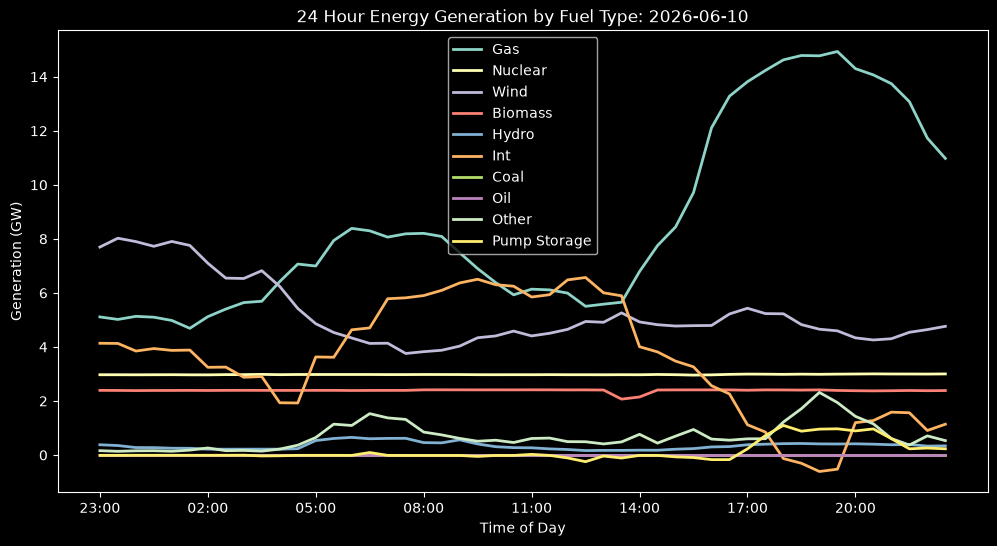

--------------
0    False
1    False
2    False
3    False
4    False
Name: Date, dtype: bool
FuelType       Date  Period     Gas  Nuclear     Int  Biomass  Hydro  Coal  \
95281    2021-06-10       1  6186.0   5765.0  3352.0   2681.0   52.0   0.0   
95282    2021-06-10       2  5707.0   5773.0  3408.0   2642.0   49.0   0.0   
95283    2021-06-10       3  5379.0   5778.0  3572.0   2557.0   48.0   0.0   
95284    2021-06-10       4  4899.0   5787.0  3668.0   2544.0   47.0   0.0   
95285    2021-06-10       5  4927.0   5784.0  3648.0   2386.0   38.0   0.0   

FuelType  Oil  Pump Storage    Wind  Other  Year  Month  Season  
95281     0.0          42.0  4273.0  142.0  2021      6  Summer  
95282     0.0        -180.0  4459.0  140.0  2021      6  Summer  
95283     0.0        -634.0  4752.0  140.0  2021      6  Summer  
95284     0.0        -746.0  4914.0  141.0  2021      6  Summer  
95285     0.0       -1026.0  4821.0  141.0  2021      6  Summer  
--------------
With time column: 

FuelTy

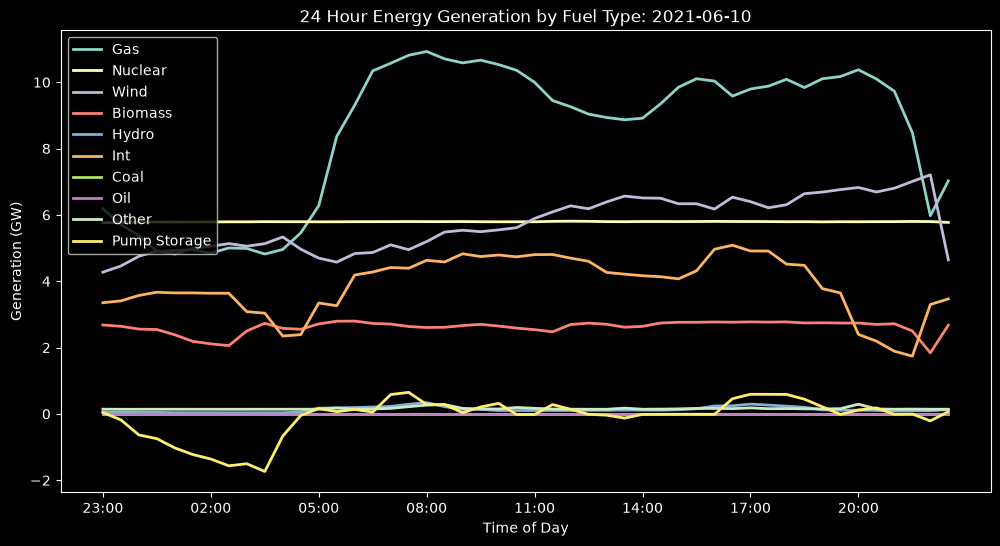

--------------------------------------------------------------------------


In [148]:
    
    
def plot_some_day(date):   
    # select some day
    print('--------------')
    
    day = date
    date_column = (final_matrix_df['Date']) # prints out the date_column in final matrix
    boolean_date_col  = date_column == day # returns boolean values in place of column
    print(boolean_date_col.head())
    
    one_day = final_matrix_df[boolean_date_col].copy() # final matrix but only the rows for that day
    print(one_day.head())
    
    print('--------------')
    
    
    '''
    # time = start time + (period number - 1) * period length
    # so period 1 matches 23:00
    
    total_minutes = (1380 + (one_day['Period'] - 1) * 30) % 1440 #
    print(total_minutes)
    
    hours = total_minutes // 60
    minutes = total_minutes % 60
    
    one_day['Time'] = hours + ':' + minutes
    print(one_day['Time'].head())
    '''
    
    
    # hard code times
    time_labels = [
        '23:00', '23:30', '00:00', '00:30', '01:00', '01:30', '02:00', '02:30', 
        '03:00', '03:30', '04:00', '04:30', '05:00', '05:30', '06:00', '06:30', 
        '07:00', '07:30', '08:00', '08:30', '09:00', '09:30', '10:00', '10:30', 
        '11:00', '11:30', '12:00', '12:30', '13:00', '13:30', '14:00', '14:30', 
        '15:00', '15:30', '16:00', '16:30', '17:00', '17:30', '18:00', '18:30', 
        '19:00', '19:30', '20:00', '20:30', '21:00', '21:30', '22:00', '22:30']
    
    # sort so that 23:00 matches 1 
    one_day = one_day.sort_values('Period') # sorts ascending by default
    
    # create a new column
    one_day ['Time'] = time_labels
    print('With time column: \n')
    print(one_day.head())
    
    # so that plot is big enough
    plt.figure(figsize=(12, 6))
    
    
    fuels_to_plot = ['Gas', 'Nuclear', 'Wind',  'Biomass', 'Hydro', 'Int', 'Coal', 'Oil', 'Other', 'Pump Storage']
    
    for fuel in fuels_to_plot:
        x_values = one_day['Time'] # acess values in time column
        y_values = one_day[fuel] / 1000  # access values in the fueltype + convert to GW
        plt.plot(x_values, y_values, label=fuel, linewidth=2) # draw a line
    
    
    # generate plots
    plt.title(f'24 Hour Energy Generation by Fuel Type: {day}')
    plt.ylabel('Generation (GW)')
    plt.xlabel('Time of Day')
    plt.xticks(ticks = range (0, 48, 6)) # show certain time column values
    plt.yticks()
    plt.legend()
    plt.show()


# choose some day 
print('Summer Day vs Winter Day')
summer_day = '2026-06-10'
winter_day = '2026-01-10'

plot_some_day(summer_day)
plot_some_day(winter_day)


print('recent day vs old day')
new_day = '2026-06-10'
old_day = '2021-06-10'

plot_some_day(new_day)
plot_some_day(old_day)









print('--------------------------------------------------------------------------')


      Name      Team  Salary
0    Alice   Celtics   50000
1      Bob    Lakers   85000
2  Charlie   Celtics   70000
3    David  Warriors  120000
Name        Alice      Bob  Charlie     David
Team                                         
Celtics   50000.0      NaN  70000.0       NaN
Lakers        NaN  85000.0      NaN       NaN
Warriors      NaN      NaN      NaN  120000.0


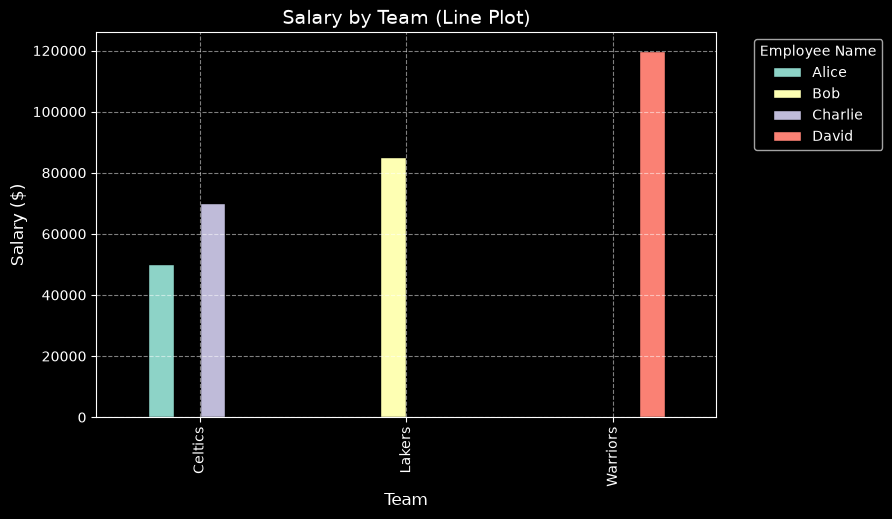

In [124]:

# sample pivot
data = {
    'Name': ['Alice', 'Bob', 'Charlie', 'David'],
    'Team': ['Celtics', 'Lakers', 'Celtics', 'Warriors'],
    'Salary': [50000, 85000, 70000, 120000]
}

df = pd.DataFrame(data)
print(df.head())


pivot_data = df.pivot( index = 'Team', columns = 'Name', values= 'Salary') # plots (x, y,z)
print(pivot_data.head())


pivot_data.plot(kind='bar', edgecolor='black', figsize=(8, 5))


plt.title('Salary by Team (Line Plot)', fontsize=14)
plt.xlabel('Team', fontsize=12)
plt.ylabel('Salary ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Employee Name', bbox_to_anchor=(1.05, 1), loc='upper left')



plt.show()


In [ ]:
# test
# sample data
x = np.linspace(0, 10, 100)
y1 = np.sin(x)
y2 = np.cos(x)

# create a single figure
plt.figure(figsize=(8, 5))

# overlay multiple plots on the same figure
plt.plot(x, y1, 'r-', label='Sine')
plt.plot(x, y2, 'b--', label='Cosine')

# add labels and a legend
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title('Sine and Cosine on Same Axes')
plt.legend()

plt.show()

# fig, ax = plt.subplots(figsize=(12, 6))
# fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
